In [1]:
import pandas as pd
from pathlib import Path

# Folder containing UNSW training and testing CSVs
folder = "/Users/HP/Desktop/Thesis/Datasets/UNSW CSV Files/Training and Testing Sets"
csv_files = list(Path(folder).glob("*.csv"))

dfs = []

# Load all CSV files in the folder
for file in csv_files:
    try:
        df = pd.read_csv(file, encoding='ISO-8859-1', low_memory=False, on_bad_lines='skip')
        dfs.append(df)
        print(f"Loaded {file.name} with shape {df.shape}")
    except Exception as e:
        print(f"Error loading {file.name}: {e}")

# Merge if multiple files
unsw_df = pd.concat(dfs, ignore_index=True)
print(f"Merged DataFrame shape: {unsw_df.shape}")

# Clean column names
unsw_df.columns = unsw_df.columns.str.strip().str.lower().str.replace(' ', '_')
print(unsw_df.head())

# Check target column (usually 'attack_cat')
if 'attack_cat' in unsw_df.columns:
    print("Unique attack categories:")
    print(unsw_df['attack_cat'].unique())
else:
    print("No 'attack_cat' column found. Check column names.")


Loaded UNSW_NB15_testing-set.csv with shape (82332, 45)
Loaded UNSW_NB15_training-set.csv with shape (175341, 45)
Merged DataFrame shape: (257673, 45)
   ï»¿id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0      1  0.000011   udp       -   INT      2      0     496       0   
1      2  0.000008   udp       -   INT      2      0    1762       0   
2      3  0.000005   udp       -   INT      2      0    1068       0   
3      4  0.000006   udp       -   INT      2      0     900       0   
4      5  0.000010   udp       -   INT      2      0    2126       0   

          rate  ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  \
0   90909.0902  ...                 1               2             0   
1  125000.0003  ...                 1               2             0   
2  200000.0051  ...                 1               3             0   
3  166666.6608  ...                 1               3             0   
4  100000.0025  ...                 1               3        

In [2]:
# ---------------------------
# UNSW-NB15 Dataset Preprocessing (Fixed)
# ---------------------------

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1️⃣ Set dataset path
data_path = Path('/Users/HP/Desktop/Thesis/Datasets/UNSW CSV Files/Training and Testing Sets')

# 2️⃣ List all CSV files
csv_files = list(data_path.glob('*.csv'))
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f)

# 3️⃣ Merge all CSV files with encoding handling
dfs = []
for file in csv_files:
    try:
        temp_df = pd.read_csv(file, encoding='utf-8', low_memory=False)
    except UnicodeDecodeError:
        temp_df = pd.read_csv(file, encoding='latin1', low_memory=False)
        print(f"File read with latin1 encoding: {file.name}")
    
    # Clean column names
    temp_df.columns = temp_df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('[^0-9a-zA-Z_]', '', regex=True)
    
    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)
print("Merged dataset shape:", df.shape)

# 4️⃣ Handle duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
df = df.drop_duplicates()

# 5️⃣ Handle missing values & infinities
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Replace inf/-inf with NaN
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Fill numeric NaNs with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical NaNs with 'unknown'
df[categorical_cols] = df[categorical_cols].fillna('unknown')

# 6️⃣ Encode categorical features (exclude target)
cat_features = [col for col in categorical_cols if col != 'attack_cat']
for col in cat_features:
    df[col] = LabelEncoder().fit_transform(df[col])

# Encode attack category as target
if 'attack_cat' in df.columns:
    le = LabelEncoder()
    df['label'] = le.fit_transform(df['attack_cat'])
    print("Attack category encoded as 'label'.")
else:
    print("No 'attack_cat' column found. Check dataset.")

# 7️⃣ Scale numeric features (exclude target 'label')
numeric_cols = [col for col in numeric_cols if col != 'label']  # exclude label
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# 8️⃣ Remove highly correlated features (>0.95)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()  # update numeric columns
numeric_cols = [col for col in numeric_cols if col != 'label']  # exclude target
corr_matrix = df[numeric_cols].corr().abs()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

print(f"Highly correlated features to drop ({len(to_drop)}): {to_drop}")
df = df.drop(columns=to_drop)
print("Dataset shape after removing correlated features:", df.shape)

# 9️⃣ Save cleaned dataset
df.to_csv('unsw_merged_cleaned_reduced_dataset.csv', index=False)
print("Cleaned and reduced UNSW dataset saved as 'unsw_merged_cleaned_reduced_dataset.csv'.")


Found 2 CSV files:
/Users/HP/Desktop/Thesis/Datasets/UNSW CSV Files/Training and Testing Sets/UNSW_NB15_testing-set.csv
/Users/HP/Desktop/Thesis/Datasets/UNSW CSV Files/Training and Testing Sets/UNSW_NB15_training-set.csv
Merged dataset shape: (257673, 45)
Duplicate rows: 0
Attack category encoded as 'label'.
Highly correlated features to drop (9): ['sbytes', 'dbytes', 'sloss', 'dloss', 'dwin', 'ct_src_dport_ltm', 'ct_dst_src_ltm', 'ct_ftp_cmd', 'ct_srv_dst']
Dataset shape after removing correlated features: (257673, 36)
Cleaned and reduced UNSW dataset saved as 'unsw_merged_cleaned_reduced_dataset.csv'.


In [3]:
df.head()

,id,dur,proto,service,state,spkts,dpkts,rate,sttl,dttl,...,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_dst_sport_ltm,is_ftp_login,ct_flw_http_mthd,ct_src_ltm,is_sm_ips_ports,attack_cat,label
0,-1.488066,-0.208678,119,0,5,-0.130765,-0.165331,-0.002151,0.722026,-0.751628,...,-0.681754,0.680262,-0.617890,-0.520051,-0.110419,-0.193597,-0.690790,-0.120335,Normal,6
1,-1.488046,-0.208679,119,0,5,-0.130765,-0.165331,0.210460,0.722026,-0.751628,...,-0.681754,0.680262,-0.617890,-0.520051,-0.110419,-0.193597,-0.690790,-0.120335,Normal,6
2,-1.488025,-0.208679,119,0,5,-0.130765,-0.165331,0.678204,0.722026,-0.751628,...,-0.589415,0.680262,-0.617890,-0.520051,-0.110419,-0.193597,-0.690790,-0.120335,Normal,6
3,-1.488005,-0.208679,119,0,5,-0.130765,-0.165331,0.470318,0.722026,-0.751628,...,-0.589415,0.680262,-0.495547,-0.520051,-0.110419,-0.193597,-0.571689,-0.120335,Normal,6
4,-1.487985,-0.208678,119,0,5,-0.130765,-0.165331,0.054546,0.722026,-0.751628,...,-0.589415,0.680262,-0.495547,-0.520051,-0.110419,-0.193597,-0.571689,-0.120335,Normal,6


Using label column for EDA: label_name

Label Distribution (Counts):
 label_name
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64

Label Distribution (%):
 label_name
Normal            36.09
Generic           22.85
Exploits          17.28
Fuzzers            9.41
DoS                6.35
Reconnaissance     5.43
Analysis           1.04
Backdoor           0.90
Shellcode          0.59
Worms              0.07
Name: count, dtype: float64


/var/folders/7d/bkg0n0453h9b7m19d0z20yy80000gn/T/ipykernel_12546/4121777895.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


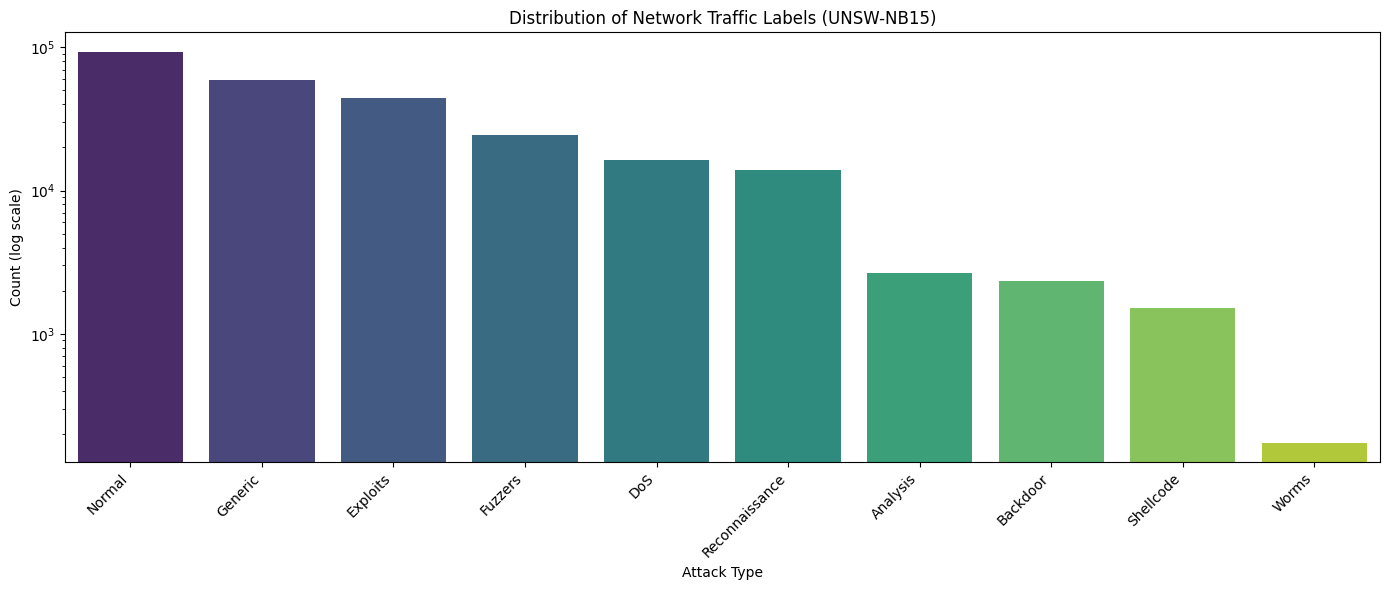

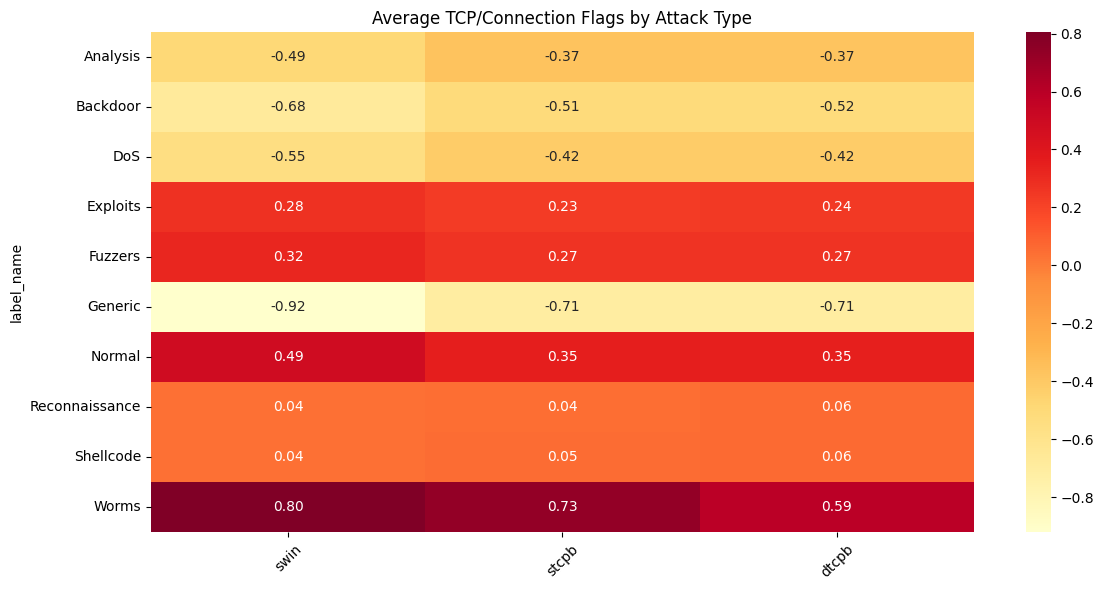


Basic Statistics by Attack Type (Packets):
                   spkts               dpkts          
                    mean       std      mean       std
label_name                                            
Analysis       -0.106088  0.089996 -0.146371  0.035483
Backdoor       -0.095698  0.136500 -0.152302  0.038912
DoS             0.031926  1.793842  0.024446  2.783611
Exploits        0.104341  2.041762  0.043409  0.980911
Fuzzers        -0.044225  0.252833 -0.110898  0.074099
Generic        -0.126523  0.152769 -0.154973  0.365895
Normal          0.057273  0.392054  0.129599  0.870262
Reconnaissance -0.093732  0.109262 -0.120827  0.634088
Shellcode      -0.101600  0.029406 -0.135959  0.030201
Worms          -0.011466  0.173786  0.396625  1.341077

Key Observations:
2. Most common attack/label: Normal (36.09%)
3. Rarest attack/label: Worms (0.07%)


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# -----------------------------
# Robust EDA for UNSW-NB15 Dataset (with attack names)
# -----------------------------

# Check for target column
if 'attack_cat' not in df.columns:
    raise ValueError("Dataset must have 'attack_cat' column for EDA.")

# Create label_name column for readable attack names
df['label_name'] = df['attack_cat']
label_col = 'label_name'
print(f"Using label column for EDA: {label_col}")

# 1️⃣ Label distribution
label_counts = df[label_col].value_counts()
print("\nLabel Distribution (Counts):\n", label_counts)
print("\nLabel Distribution (%):\n", (label_counts / len(df) * 100).round(2))

plt.figure(figsize=(14,6))
sns.countplot(
    x=label_col,
    data=df,
    order=label_counts.index,
    palette="viridis"
)
plt.title('Distribution of Network Traffic Labels (UNSW-NB15)')
plt.xlabel('Attack Type')
plt.ylabel('Count (log scale)')
plt.yscale('log')  # log scale for imbalanced dataset
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3️⃣ TCP/connection flags heatmap (auto-detect)
possible_flags = ['swin', 'dwin', 'stcpb', 'dtcpb']  # common UNSW flags
existing_flags = [f for f in possible_flags if f in df.columns]
if existing_flags:
    flag_means = df.groupby(label_col)[existing_flags].mean()
    plt.figure(figsize=(12,6))
    sns.heatmap(flag_means, annot=True, fmt='.2f', cmap='YlOrRd')
    plt.title('Average TCP/Connection Flags by Attack Type')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 4️⃣ Summary statistics for packet counts
packet_cols = [f for f in ['spkts', 'dpkts'] if f in df.columns]
if packet_cols:
    attack_stats = df.groupby(label_col)[packet_cols].agg(['mean','std'])
    print("\nBasic Statistics by Attack Type (Packets):")
    print(attack_stats)

# 5️⃣ Packet size statistics
packet_size_cols = [f for f in ['sbytes', 'dbytes'] if f in df.columns]
if packet_size_cols:
    packet_stats = df.groupby(label_col)[packet_size_cols].agg(['mean','std','min','max'])
    print("\nPacket Size Analysis by Attack Type:")
    print(packet_stats)

# 6️⃣ Key Observations
total = len(df)
most_common = label_counts.idxmax()
rarest = label_counts.idxmin()
print("\nKey Observations:")
if 'BENIGN' in label_counts.index:
    print(f"1. Benign traffic comprises {label_counts['BENIGN']/total:.2%} of the dataset")
print(f"2. Most common attack/label: {most_common} ({label_counts[most_common]/total:.2%})")
print(f"3. Rarest attack/label: {rarest} ({label_counts[rarest]/total:.2%})")


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

if label_col:
    print("Column names:", df.columns.tolist())
    
    # Display counts and percentages
    label_counts = df[label_col].value_counts()
    print("\nLabel Distribution (Counts):\n", label_counts)
    print("\nLabel Distribution (%):\n", (label_counts / len(df) * 100).round(2))

Column names: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_flw_http_mthd', 'ct_src_ltm', 'is_sm_ips_ports', 'attack_cat', 'label', 'label_name']

Label Distribution (Counts):
 label_name
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64

Label Distribution (%):
 label_name
Normal            36.09
Generic           22.85
Exploits          17.28
Fuzzers            9.41
DoS                6.35
Reconnaissance     5.43
Analysis           1.04
Backdoor           0.90
Shellcode          0.59
Worms 

In [6]:
# Import necessary libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [7]:
# ==========================
# 0️⃣ Imports
# ==========================
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib

# ==========================
# 1️⃣ Ensure dataset loaded
# ==========================
# df = pd.read_csv("your_dataset.csv")  # Uncomment if loading here
if 'label' not in df.columns:
    raise ValueError("Dataset must have a 'label' column")

# ==========================
# 2️⃣ Clean labels
# ==========================
df['label'] = df['label'].astype(str).str.strip().str.upper()

# Merge very rare classes into 'RARE' (<=5 samples)
counts = df['label'].value_counts()
rare_classes = counts[counts <= 5].index
df['label'] = df['label'].apply(lambda x: 'RARE' if x in rare_classes else x)

# Remove any classes that still have <=1 sample
counts = df['label'].value_counts()
df = df[df['label'].isin(counts[counts > 1].index)]

# ==========================
# 3️⃣ Reduce dataset to 50% for memory efficiency
# ==========================
df, _ = train_test_split(df, train_size=0.5, stratify=df['label'], random_state=42)
print(f"Working with {len(df)} samples (50% of original dataset)")

# ==========================
# 4️⃣ Encode labels
# ==========================
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['label'])

# Save label encoder for later mapping predictions
joblib.dump(le, "label_encoder.pkl")

# ==========================
# 5️⃣ Features and target
# ==========================
X = df.drop(columns=['label', 'Label_encoded'], errors='ignore')
y = df['Label_encoded']

# One-hot encode categorical features
categorical_cols = X.select_dtypes(include='object').columns
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# ==========================
# 6️⃣ Train/test split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train/test split done.")
print("Train class distribution:", Counter(y_train))
print("Test class distribution:", Counter(y_test))

# ==========================
# 7️⃣ Scale numeric features
# ==========================
numeric_cols = X_train.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Save scaler for later use
joblib.dump(scaler, "scaler.pkl")

print("✅ Preprocessing complete. Features scaled and ready for modeling.")


Working with 128836 samples (50% of original dataset)
Train/test split done.
Train class distribution: Counter({6: 37200, 5: 23548, 3: 17809, 4: 9698, 2: 6541, 7: 5594, 0: 1071, 1: 932, 8: 605, 9: 70})
Test class distribution: Counter({6: 9300, 5: 5887, 3: 4453, 4: 2425, 2: 1635, 7: 1399, 0: 268, 1: 233, 8: 151, 9: 17})
✅ Preprocessing complete. Features scaled and ready for modeling.


In [8]:
# ==========================
# 7️⃣ Feature scaling
# ==========================
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import joblib
import numpy as np

# Identify numeric columns
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# ColumnTransformer: scale numeric features, leave others unchanged
scaler = StandardScaler()
ct = ColumnTransformer([
    ('num', scaler, numeric_cols)
], remainder='passthrough')  # keep non-numeric columns as-is

# Fit on training set
X_train_scaled = ct.fit_transform(X_train)
X_test_scaled = ct.transform(X_test)

# Save scaler pipeline
joblib.dump(ct, 'scaler_pipeline.pkl')
print("✅ Feature scaling done for numeric columns.")

# ==========================
# 8️⃣ Check class imbalance
# ==========================
from collections import Counter
class_counts = Counter(y_train)
print("Train class distribution before SMOTE:", class_counts)

# ==========================
# 9️⃣ Apply SMOTE with dynamic k_neighbors
# ==========================
from imblearn.over_sampling import SMOTE

min_class_count = min(class_counts.values())
# SMOTE requires k_neighbors < min_class_count
k_neighbors = min(5, min_class_count - 1) if min_class_count > 1 else 1

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Train class distribution after SMOTE:", Counter(y_train_resampled))
print("✅ SMOTE applied successfully with k_neighbors =", k_neighbors)


✅ Feature scaling done for numeric columns.
Train class distribution before SMOTE: Counter({6: 37200, 5: 23548, 3: 17809, 4: 9698, 2: 6541, 7: 5594, 0: 1071, 1: 932, 8: 605, 9: 70})
Train class distribution after SMOTE: Counter({1: 37200, 3: 37200, 7: 37200, 6: 37200, 5: 37200, 4: 37200, 2: 37200, 8: 37200, 0: 37200, 9: 37200})
✅ SMOTE applied successfully with k_neighbors = 5


Training model...
Train Accuracy: 0.876090737994753
Test Accuracy: 0.8358664347429353

Classification Report:

                precision    recall  f1-score   support

      Analysis       0.71      0.14      0.23       400
      Backdoor       0.88      0.12      0.21       349
           DoS       0.40      0.14      0.20      2453
      Exploits       0.63      0.91      0.74      6679
       Fuzzers       0.78      0.76      0.77      3637
       Generic       1.00      0.98      0.99      8000
        Normal       0.95      0.93      0.94     11200
Reconnaissance       0.92      0.75      0.82      2098
     Shellcode       0.70      0.74      0.72       227
         Worms       0.63      0.46      0.53        26

      accuracy                           0.84     35069
     macro avg       0.76      0.59      0.62     35069
  weighted avg       0.83      0.84      0.82     35069



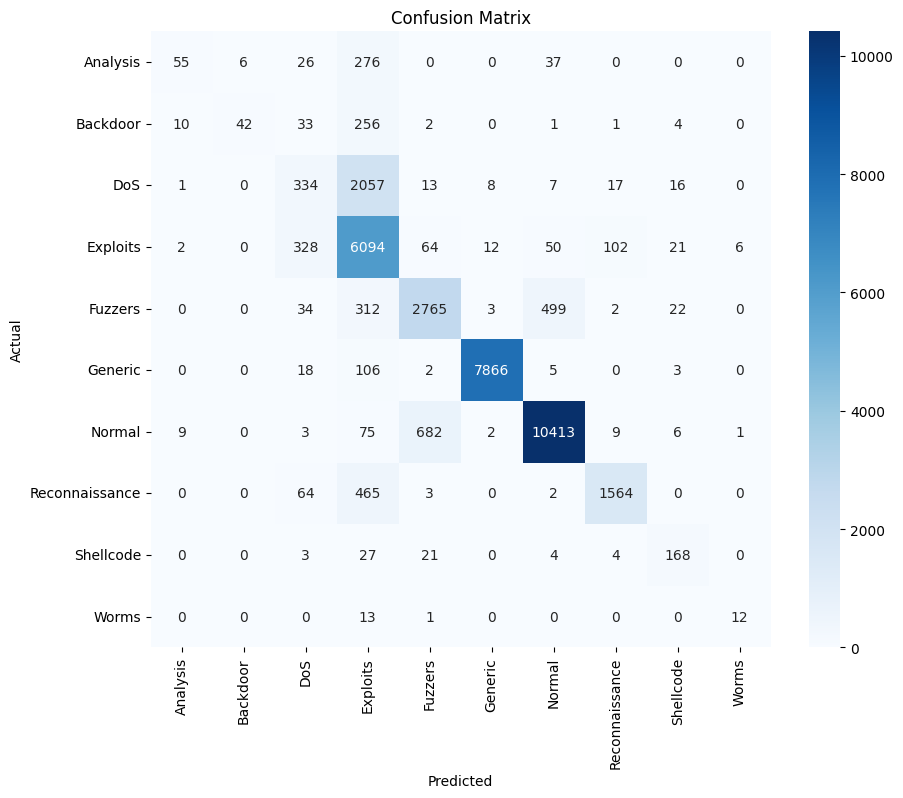

✅ Pipeline, label encoder, and class names saved!


In [9]:
# ==========================
# UNSW-NB15 ML Training Pipeline (Deployment Ready)
# ==========================

import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

# --------------------------
# 1️⃣ Load dataset
# --------------------------
df = pd.read_csv("UNSW_NB15_training-set.csv")

# --------------------------
# 2️⃣ Define features
# --------------------------
numeric_features = [
    'dur','spkts','dpkts','sbytes','dbytes','rate','sttl','dttl','sload','dload',
    'sloss','dloss','sinpkt','dinpkt','sjit','djit','swin','stcpb','dtcpb','dwin',
    'tcprtt','synack','ackdat','smean','dmean','trans_depth','response_body_len',
    'ct_srv_src','ct_state_ttl','ct_dst_ltm','ct_src_dport_ltm','ct_dst_sport_ltm',
    'ct_dst_src_ltm','ct_src_ltm','ct_srv_dst'
]

categorical_features = [
    'proto','service','state','is_ftp_login','ct_ftp_cmd','ct_flw_http_mthd','is_sm_ips_ports'
]

all_features = numeric_features + categorical_features

# --------------------------
# 3️⃣ Define X and y
# --------------------------
X = df[all_features]
y = df['attack_cat']   # multiclass labels

# Encode target labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# --------------------------
# 4️⃣ Build preprocessor pipeline
# --------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# --------------------------
# 5️⃣ Build model pipeline
# --------------------------
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',  
    num_class=len(le.classes_),
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

# --------------------------
# 6️⃣ Train/test split
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# --------------------------
# 7️⃣ Train model
# --------------------------
print("Training model...")
pipeline.fit(X_train, y_train)

# --------------------------
# 8️⃣ Evaluate model
# --------------------------
print("Train Accuracy:", pipeline.score(X_train, y_train))
print("Test Accuracy:", pipeline.score(X_test, y_test))

y_pred = pipeline.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# --------------------------
# 9️⃣ Save preprocessing + model
# --------------------------
joblib.dump(pipeline, "unsw_pipeline_xgb.pkl")
joblib.dump(le, "unsw_label_encoder.pkl")
joblib.dump(le.classes_, "label_classes.pkl")
print("✅ Pipeline, label encoder, and class names saved!")

# --------------------------
# 🔟 Deployment-ready prediction function
# --------------------------
def predict_new_sample(new_sample_dict):
    """
    Predict label for new input features.
    new_sample_dict: dict {feature_name: value}
    """
    input_df = pd.DataFrame([new_sample_dict], columns=all_features)
    pred_encoded = pipeline.predict(input_df)
    pred_label = le.inverse_transform(pred_encoded)
    return pred_label[0]

# Example usage:
# sample = dict(zip(all_features, X_test.iloc[0]))
# print("Predicted label:", predict_new_sample(sample))


Classification Report - XGBoost:

                precision    recall  f1-score   support

      Analysis       0.71      0.14      0.23       400
      Backdoor       0.88      0.12      0.21       349
           DoS       0.40      0.14      0.20      2453
      Exploits       0.63      0.91      0.74      6679
       Fuzzers       0.78      0.76      0.77      3637
       Generic       1.00      0.98      0.99      8000
        Normal       0.95      0.93      0.94     11200
Reconnaissance       0.92      0.75      0.82      2098
     Shellcode       0.70      0.74      0.72       227
         Worms       0.63      0.46      0.53        26

      accuracy                           0.84     35069
     macro avg       0.76      0.59      0.62     35069
  weighted avg       0.83      0.84      0.82     35069



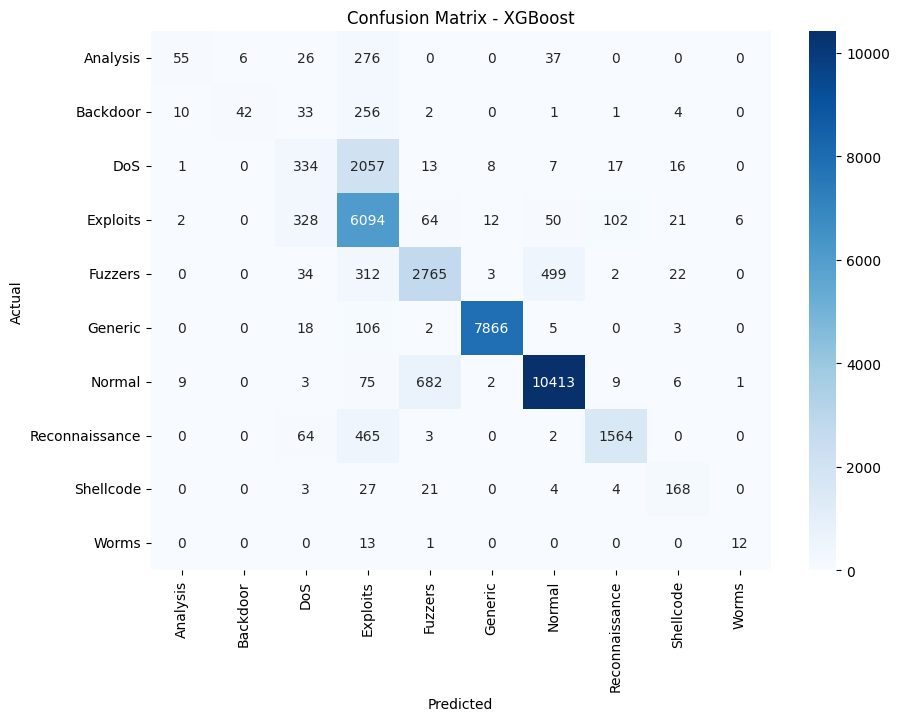

ROC-AUC Score: 0.9640
✅ Pipeline, label encoder, and class names saved.


In [10]:
# ==========================
# 11️⃣ Detailed evaluation of best model (robust version)
# ==========================
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Predict directly using the pipeline (scaling + encoding already handled)
y_pred = pipeline.predict(X_test)

# Classification Report
print(f"Classification Report - XGBoost:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - XGBoost")
plt.show()

# ROC-AUC (multi-class)
try:
    if len(le.classes_) > 2:
        y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
        y_pred_prob = pipeline.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test_bin, y_pred_prob, average='macro', multi_class='ovr')
    else:
        y_pred_prob = pipeline.predict_proba(X_test)[:,1]
        roc_auc = roc_auc_score(y_test, y_pred_prob)
    print(f"ROC-AUC Score: {roc_auc:.4f}")
except AttributeError:
    print("Model does not support predict_proba; skipping ROC-AUC calculation.")

# ==========================
# 12️⃣ Save preprocessing objects
# ==========================
import joblib
joblib.dump(pipeline, 'unsw_pipeline_xgb.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(le.classes_, 'label_classes.pkl')
print("✅ Pipeline, label encoder, and class names saved.")

# ==========================
# 13️⃣ Deployment-ready predict function
# ==========================
def predict_new_sample(input_features):
    """
    Predict label for new input features.
    
    Parameters:
        input_features (dict): {feature_name: value}
    
    Returns:
        str: Predicted class label
    """
    input_df = pd.DataFrame([input_features])
    pred_encoded = pipeline.predict(input_df)
    pred_label = le.inverse_transform(pred_encoded)
    return pred_label[0]

# Example usage:
# sample = dict(zip(all_features, X_test.iloc[0]))
# print("Predicted label:", predict_new_sample(sample))


In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 📂 Load your dataset (adjust the file name/path)
df_all = pd.read_csv("UNSW_NB15_training-set.csv")

# Use 'attack_cat' as the label column
label_col = 'attack_cat'

# Check unique labels first
print("Original labels:", df_all[label_col].unique())

# Initialize label encoder
le = LabelEncoder()

# Fit and transform the labels to numeric values
df_all['Label_encoded'] = le.fit_transform(df_all[label_col])

# Show mapping
print("Label mapping:")
for i, class_name in enumerate(le.classes_):
    print(f"{i} → {class_name}")


Original labels: ['Normal' 'Backdoor' 'Analysis' 'Fuzzers' 'Shellcode' 'Reconnaissance'
 'Exploits' 'DoS' 'Worms' 'Generic']
Label mapping:
0 → Analysis
1 → Backdoor
2 → DoS
3 → Exploits
4 → Fuzzers
5 → Generic
6 → Normal
7 → Reconnaissance
8 → Shellcode
9 → Worms


In [12]:
print("Features used for training:", X_train.columns.tolist())
print("Number of features:", len(X_train.columns))


Features used for training: ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst', 'proto', 'service', 'state', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports']
Number of features: 42


In [13]:
import pandas as pd

# Load your dataset
df = pd.read_csv('/Users/HP/Desktop/Thesis/Datasets/UNSW CSV Files/Training and Testing Sets/UNSW_NB15_training-set.csv', encoding='ISO-8859-1')  # or 'latin1' if utf-8 fails

# Remove whitespace from column names
df.columns = df.columns.str.strip()

# Print the exact column order
print(df.columns.tolist())


['ï»¿id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [14]:
X = df.drop(columns=['label', 'Label_encoded'], errors='ignore')
print("Features used for training:", X.columns.tolist())
print("Number of features:", len(X.columns))


Features used for training: ['ï»¿id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat']
Number of features: 44
